In [111]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from math import floor
import matplotlib.pyplot as plt
import numpy as np


def convolve(
    x: torch.Tensor,
    filt: torch.Tensor,                  # shape: (BS, CH, kH, kW)
    mode: str = "same",                  # {"valid","same","full"} (SciPy-style)
    boundary: str = "fill",              # {"fill","wrap","symm","replicate"}
    fillvalue: float = 0.0
) -> torch.Tensor:
    """
    Vectorised 2D convolution with one kernel per (batch,channel).
    x:     (BS, CH, H, W)
    filt:  (BS, CH, kH, kW)  — each (b,c) gets its own kernel
    Returns: y with SciPy-like sizing semantics for mode.
    """
    assert x.ndim == 4 and filt.ndim == 4, "x: (BS,CH,H,W), filt: (BS,CH,kH,kW)"
    BS, CH, H, W = x.shape
    assert filt.shape[0] == BS and filt.shape[1] == CH, "filt must be per-(b,c)"
    kH, kW = filt.shape[-2:]

    # PyTorch conv2d is cross-correlation; flip to implement convolution.
    w = torch.flip(filt.to(x.dtype).to(x.device), dims=(-1, -2))           # (BS,CH,kH,kW)
    w = w.reshape(BS * CH, 1, kH, kW)                                      # groups kernels

    # Padding to emulate SciPy's mode/boundary
    if mode == "valid":
        pad_h = pad_w = 0
    elif mode == "same":
        # Centre-aligned "same"; for even kernels this matches floor((k-1)/2).
        pad_h = (kH - 1) // 2
        pad_w = (kW - 1) // 2
    elif mode == "full":
        pad_h = kH - 1
        pad_w = kW - 1
    else:
        raise ValueError("mode must be one of {'valid','same','full'}")

    if boundary == "wrap":
        x_pad = F.pad(x, (pad_w, pad_w, pad_h, pad_h), mode="circular")
    elif boundary == "symm":
        # SciPy's 'symm' is symmetric reflect; PyTorch 'reflect' is the closest.
        x_pad = F.pad(x, (pad_w, pad_w, pad_h, pad_h), mode="reflect")
    elif boundary == "replicate":
        x_pad = F.pad(x, (pad_w, pad_w, pad_h, pad_h), mode="replicate")
    elif boundary == "fill":
        x_pad = F.pad(x, (pad_w, pad_w, pad_h, pad_h), mode="constant", value=fillvalue)
    else:
        raise ValueError("boundary must be {'fill','wrap','symm','replicate'}")

    # Fold (BS,CH) into groups, convolve, then unfold back.
    y = F.conv2d(
        x_pad.view(1, BS * CH, x_pad.shape[-2], x_pad.shape[-1]),
        w, bias=None, stride=1, padding=0, groups=BS * CH
    ).view(BS, CH, H, W)

    # Output size follows padding choice; nothing further to trim for "same"/"full".
    return y


def rms(x):
    square = torch.pow(x, 2)
    mean_square = torch.mean(square)
    rms = torch.sqrt(mean_square)
    return rms.item()


def pad_signal(x, shape, val=0):
    """
    Pad only spatial dimensions of shape [B, C, D1, D2, ...]
    """
    assert len(shape) == len(x.shape), f"Expected shape {len(shape)}, got {len(x.shape)}"

    pad = []
    for i in range(2, len(x.shape)):  # Skip batch and channel
        p1 = floor((shape[i] - x.shape[i]) / 2)
        p2 = shape[i] - x.shape[i] - p1
        pad.extend((p1, p2))

    pad = pad[::-1]  # Reverse for torch.nn.functional.pad
    return nn.functional.pad(x, pad, value=val)

import torch
import torch.nn.functional as F

def wienerfft_stable(x, y, fs, lmbda=1e-4):
    """
    Per-(batch,channel) Wiener-type deconvolution kernel h such that y ≈ h * x
    (circular convolution on the given grid), with a robust denominator floor.

    No padding is performed; the caller is responsible for any external padding.
    After computing h, a half-size roll is applied per spatial dimension, using
    the sizes provided by `fs` (interpreted as the spatial filter size tuple).

    Args:
        x, y: tensors of shape (B, C, *spatial), same shape & device. Real or complex.
        fs:   iterable of spatial sizes (e.g. (H, W) or (D, H, W)) for the filter.
              Typically this should equal x.shape[2:].
        lmbda: non-negative stabiliser (dimensionless), scaled by median S_xx.

    Returns:
        h_rolled: real tensor of shape (B, C, *spatial), half-size rolled.
    """
    assert x.shape == y.shape, "x and y must have the same shape"
    assert x.ndim >= 3, "expected (B, C, *spatial)"
    fs = tuple(int(s) for s in fs)
    spatial_shape = x.shape[2:]
    assert tuple(spatial_shape) == fs, (
        f"`fs` must match the spatial shape of x/y; got fs={fs}, data={spatial_shape}"
    )

    dims = tuple(range(2, x.ndim))  # spatial dims

    # Promote to floating/complex dtype consistently
    if not torch.is_complex(x):
        x = x.to(torch.get_default_dtype())
        y = y.to(torch.get_default_dtype())

    Fx = torch.fft.fftn(x, dim=dims, norm="ortho")
    Fy = torch.fft.fftn(y, dim=dims, norm="ortho")

    # For y ≈ h * x: Y = H·X ⇒ H ≈ S_yx / S_xx
    S_yx = Fy * Fx.conj()
    S_xx = (Fx * Fx.conj()).real  # ≥ 0 up to round-off

    # Robust per-(B,C) median power as a floor reference
    med_power = S_xx
    for d in reversed(dims):
        med_power = med_power.median(dim=d, keepdim=True).values
    med_power = med_power.clamp_min(torch.finfo(S_xx.dtype).tiny).detach()

    # Strictly positive floor via softplus
    floor = F.softplus(
        torch.as_tensor(lmbda, dtype=S_xx.dtype, device=S_xx.device)
    ) * med_power

    denom = S_xx + floor

    # Optionally mute frequencies where X is vanishing
    tiny = 10.0 * torch.finfo(S_xx.dtype).eps
    mask_quiet = (S_xx <= tiny * med_power)

    H = torch.where(mask_quiet, torch.zeros_like(S_yx), S_yx / denom)

    # Back to spatial kernel; keep real part (imaginary part is numerical noise)
    h = torch.fft.ifftn(H, dim=dims, norm="ortho").real

    # Apply half-size roll per spatial dimension (centre impulse at geometric centre)
    shifts = tuple(-(n // 2) for n in fs)
    h_rolled = torch.roll(h, shifts=shifts, dims=dims)

    return h_rolled

import torch
import torch.nn.functional as F

def wienerfft_stable_2(x, y, fs, lmbda=1e-4, tau=1e-3, max_gain=None, return_real=None):
    """
    Per-(B,C) Wiener deconvolution kernel h for circular convolution y ≈ h * x.
    No padding/centering inside. Works for real or complex inputs.
    - lmbda: dimensionless regulariser (relative floor strength).
    - tau:   softness of the floor's absolute component (fraction of max S_xx).
    - max_gain: optional cap on |H| via 1/(S_xx+floor) ≤ 1/(gain_floor).
    - return_real: if None, auto: True iff both x,y are real; else obey flag.
    """
    assert x.shape == y.shape and x.ndim >= 3
    dims = tuple(range(2, x.ndim))

    # Promote to floating/complex as needed (torch.fft handles real->complex)
    x = x.to(torch.get_default_dtype())
    y = y.to(torch.get_default_dtype())

    Fx = torch.fft.fftn(x, dim=dims, norm="ortho")
    Fy = torch.fft.fftn(y, dim=dims, norm="ortho")

    S_yx = Fy * Fx.conj()
    S_xx = (Fx * Fx.conj()).real  # ≥ 0 (up to roundoff)

    # Robust per-(B,C) scale: mix of percentile and mean to avoid degeneracy
    # Keep dims for broadcast
    def reduce_keep(t, dim):
        return t.quantile(0.5, dim=dim, keepdim=True)  # median
    med = S_xx
    for d in dims[::-1]:
        med = reduce_keep(med, d)
    mean_pow = S_xx
    for d in dims[::-1]:
        mean_pow = mean_pow.mean(dim=d, keepdim=True)

    # Absolute and relative components of the floor
    eps = torch.finfo(S_xx.dtype).eps
    scale = torch.maximum(med, mean_pow)  # robust energy proxy
    rel_floor = max(lmbda, 0.0) * scale.detach()
    abs_floor = tau * (S_xx.amax(dim=dims, keepdim=True).detach() + eps)

    floor = rel_floor + abs_floor  # strictly positive and not vanishing

    denom = S_xx + floor

    # Optional: cap deconvolution gain to avoid huge |H|
    if max_gain is not None:
        # Equivalent to ensuring 1/denom ≤ max_gain / |S_yx| in worst case;
        # simpler: lower-bound denom by scale/max_gain.
        gain_floor = (scale / max_gain).clamp_min(eps)  # broadcastable
        denom = torch.maximum(denom, gain_floor)

    # Smooth attenuation instead of hard zeros:
    H = S_yx / denom  # Wiener form; small S_xx naturally down-weights

    h = torch.fft.ifftn(H, dim=dims, norm="ortho")
    if return_real is None:
        return_real = (not torch.is_complex(x)) and (not torch.is_complex(y))

    # Apply half-size roll per spatial dimension (centre impulse at geometric centre)
    shifts = tuple(-(n // 2) for n in fs)
    h_rolled = torch.roll(h, shifts=shifts, dims=dims)

    h_rolled = h_rolled / torch.max(h_rolled.real) * torch.sign(h_rolled.real)

    return h_rolled.real if return_real else h_rolled

def wienerfft(x, y, fs, lmbda=1e-4, corr_norm=False):
    assert x.shape == y.shape, "x and y must have the same shape"
    B, C = x.shape[:2]

    filter_dim = len(x.shape) - 2
    dims = tuple(range(2, 2 + filter_dim))

    Fx = torch.fft.fftn(x, dim=dims)
    Fy = torch.fft.fftn(y, dim=dims)
    Fccorr = Fx * torch.conj(Fy)
    Facorr = Fx * torch.conj(Fx)

    rms_ = rms(torch.abs(Fccorr))
    if corr_norm:
        Fccorr = Fccorr / rms_
        Facorr = Facorr / rms_

    lmbda_scaled = lmbda * rms_
    Fdconv = (Fccorr + lmbda_scaled) / (Facorr + lmbda_scaled)

    rolled = torch.fft.irfftn(Fdconv, fs[1:], dim=dims)
    shifts = tuple(-fs[i+1] // 2 for i in range(filter_dim))
    return torch.roll(rolled, shifts, dims=dims)

In [132]:
def run_exp(x, y, fs_, **kwargs):

    x_pad = pad_signal(x, (1, 1, fs_, fs_))
    y_pad = pad_signal(y, (1, 1, fs_, fs_))

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    w_stable = wienerfft_stable(x_pad, y_pad, fs=(fs_, fs_), lmbda=0.)
    print(x_pad.shape, w_stable.shape, y_pad.shape)
    recon = convolve(x, w_stable, mode="same")
    print("Reconstruction error (stable):", torch.norm(recon - y_pad).item())
    w_stable = w_stable.mean(dim=[0, 1], keepdim=False)  # Average over batch
    max_ = torch.max(torch.abs(w_stable))
    axs[0].plot(w_stable.cpu().flatten())
    axs[0].set_title("Wiener FFT (Stable)")

    w_stable_2 = wienerfft_stable_2(x_pad, y_pad, fs=(fs_, fs_), lmbda=0.)
    w_stable_2 = w_stable_2.mean(dim=[0, 1], keepdim=False)  # Average over batch
    max_ = torch.max(torch.abs(w_stable_2))
    axs[1].plot(w_stable_2.cpu().flatten())
    axs[1].set_title("Wiener FFT (Stable 2)")

    w_standard = wienerfft(x_pad, y_pad, fs=(1, fs_, fs_), lmbda=0.)
    w_standard = w_standard.mean(dim=[0, 1], keepdim=False)  # Average over batch
    max_ = torch.max(torch.abs(w_standard))
    axs[2].plot(w_standard.cpu().flatten())
    axs[2].set_title("Wiener FFT (Standard)")

    plt.show()


In [133]:
fs_ = 22
x = torch.randn(15, 3, 21, 21)

torch.Size([15, 3, 22, 22]) torch.Size([15, 3, 22, 22]) torch.Size([15, 3, 22, 22])


RuntimeError: shape '[15, 3, 21, 21]' is invalid for input of size 18000

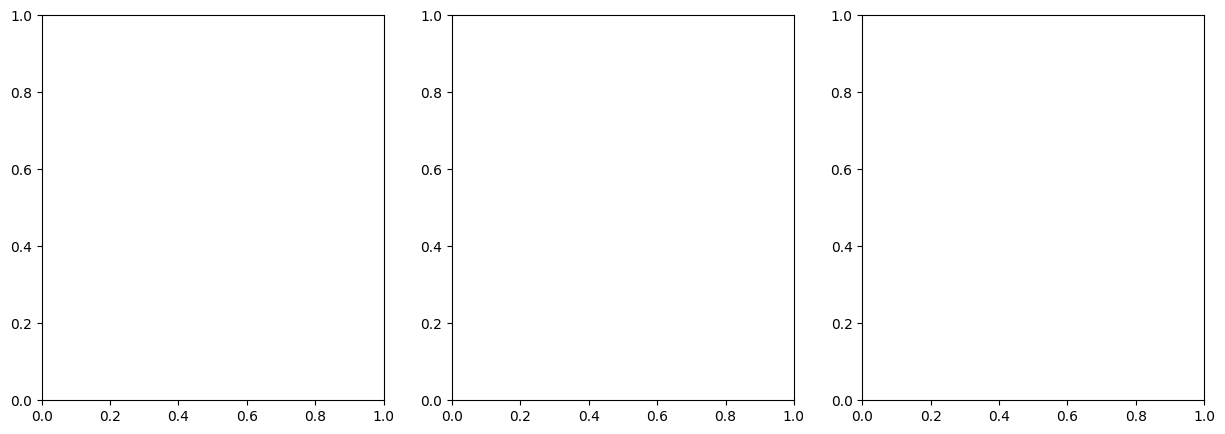

In [135]:
y = x[:] * 2



# print(x_pad.shape, y_pad.shape)

# convolve(x_pad, y_pad, "same")

run_exp(x, y, fs_)

torch.Size([15, 15, 1, 1]) torch.Size([15, 3, 32, 32])


RuntimeError: The size of tensor a (15) must match the size of tensor b (3) at non-singleton dimension 1

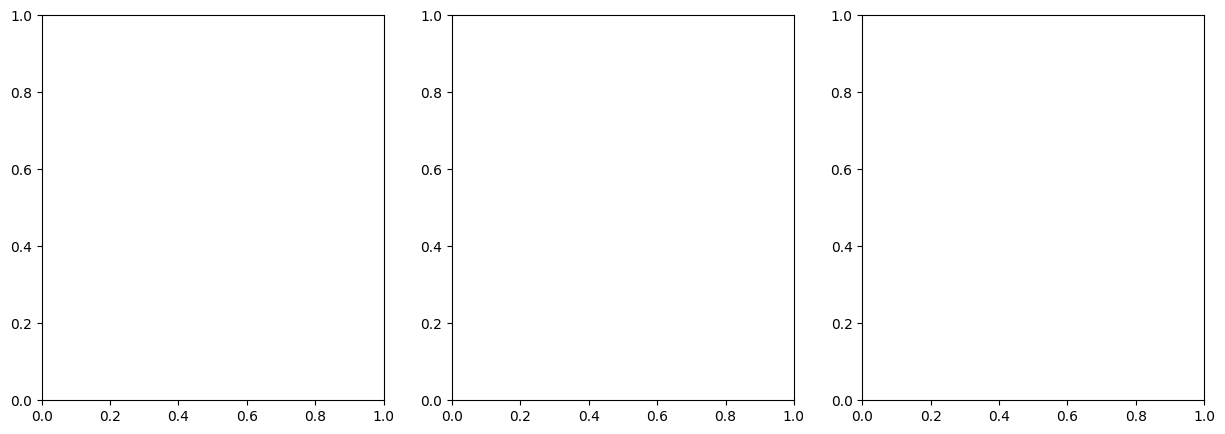

In [98]:
# shift x by 1 pixel in each of the last 2 dimensions
y = torch.roll(x, shifts=(5, 5), dims=(2, 3))

x_pad = pad_signal(x, (1, 1, fs_, fs_))
y_pad = pad_signal(y, (1, 1, fs_, fs_))

run_exp(x_pad, y_pad, fs_)


In [125]:
import torch
import torch.nn.functional as F

def convolve(
    x: torch.Tensor,
    filt: torch.Tensor,                  # shape: (BS, CH, kH, kW)
    mode: str = "same",                  # {"valid","same","full"} (SciPy-style)
    boundary: str = "fill",              # {"fill","wrap","symm","replicate"}
    fillvalue: float = 0.0
) -> torch.Tensor:
    """
    Vectorised 2D convolution with one kernel per (batch,channel).
    x:     (BS, CH, H, W)
    filt:  (BS, CH, kH, kW)  — each (b,c) gets its own kernel
    Returns: y with SciPy-like sizing semantics for mode.
    """
    assert x.ndim == 4 and filt.ndim == 4, "x: (BS,CH,H,W), filt: (BS,CH,kH,kW)"
    BS, CH, H, W = x.shape
    assert filt.shape[0] == BS and filt.shape[1] == CH, "filt must be per-(b,c)"
    kH, kW = filt.shape[-2:]

    # PyTorch conv2d is cross-correlation; flip to implement convolution.
    w = torch.flip(filt.to(x.dtype).to(x.device), dims=(-1, -2))           # (BS,CH,kH,kW)
    w = w.reshape(BS * CH, 1, kH, kW)                                      # groups kernels

    # Padding to emulate SciPy's mode/boundary
    if mode == "valid":
        pad_h = pad_w = 0
    elif mode == "same":
        # Centre-aligned "same"; for even kernels this matches floor((k-1)/2).
        pad_h = (kH - 1) // 2
        pad_w = (kW - 1) // 2
    elif mode == "full":
        pad_h = kH - 1
        pad_w = kW - 1
    else:
        raise ValueError("mode must be one of {'valid','same','full'}")

    if boundary == "wrap":
        x_pad = F.pad(x, (pad_w, pad_w, pad_h, pad_h), mode="circular")
    elif boundary == "symm":
        # SciPy's 'symm' is symmetric reflect; PyTorch 'reflect' is the closest.
        x_pad = F.pad(x, (pad_w, pad_w, pad_h, pad_h), mode="reflect")
    elif boundary == "replicate":
        x_pad = F.pad(x, (pad_w, pad_w, pad_h, pad_h), mode="replicate")
    elif boundary == "fill":
        x_pad = F.pad(x, (pad_w, pad_w, pad_h, pad_h), mode="constant", value=fillvalue)
    else:
        raise ValueError("boundary must be {'fill','wrap','symm','replicate'}")

    # Fold (BS,CH) into groups, convolve, then unfold back.
    y = F.conv2d(
        x_pad.view(1, BS * CH, x_pad.shape[-2], x_pad.shape[-1]),
        w, bias=None, stride=1, padding=0, groups=BS * CH
    ).view(BS, CH, H, W)

    # Output size follows padding choice; nothing further to trim for "same"/"full".
    return y

torch.Size([15, 3, 21, 21]) torch.Size([15, 3, 21, 21])
0.0


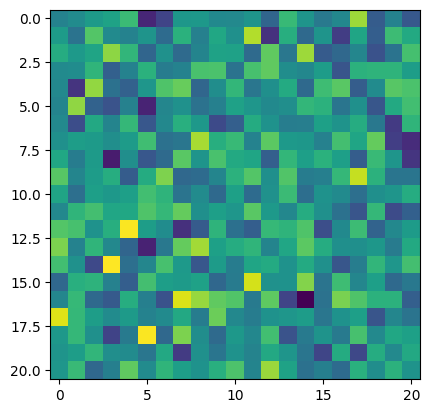

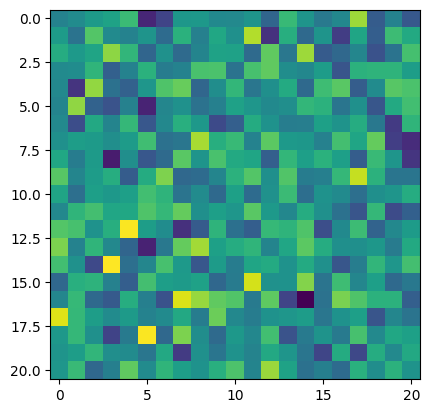

In [126]:
delta = torch.zeros_like(x)
h, w = delta.shape[2:]
delta[..., h//2, w//2] = 1.

print(x.shape, delta.shape)

y = convolve(x, delta, mode="same", boundary="fill", fillvalue=0.)

print(torch.norm(y**2 - x**2).item())

plt.imshow(x[0, 0].cpu().numpy()); plt.show()
plt.imshow(y[0, 0].cpu().numpy()); plt.show()


In [ ]:
x = torch.randn(15, 3, 16, 16)
fs_ = 32

v = torch.randn(15, 3, fs_, fs_)

x_pad = pad_signal(x, (1, 1, fs_, fs_))
y_pad = torch.conv2d(x_pad, v, padding=0, )
print(y_pad.shape)
# y_pad = pad_signal(y, (1, 1, fs_, fs_))



# delta = torch.zeros(1, 1, fs_, fs_)
# delta[..., fs_//2, fs_//2] = 1.
# delta = delta.flatten()

# print(x_pad.shape, y_pad.shape)

# w_stable = wienerfft_stable(x_pad, y_pad, fs=(fs_, fs_), lmbda=0.)
# w_stable = w_stable.mean(dim=[0, 1], keepdim=False)  # Average over batch
# max_ = torch.max(torch.abs(w_stable))
# plt.plot(w_stable.cpu().flatten())#, cmap='seismic', vmin=-torch.max(torch.abs(w_stable)), vmax=torch.max(torch.abs(w_stable)))
# plt.show()

# w_stable_2 = wienerfft_stable_2(x_pad, y_pad, fs=(fs_, fs_), lmbda=0.)
# w_stable_2 = w_stable_2.mean(dim=[0, 1], keepdim=False)  # Average over batch
# max_ = torch.max(torch.abs(w_stable_2))
# plt.plot(w_stable_2.cpu().flatten())#, cmap='seismic', vmin=-torch.max(torch.abs(w_stable_2)), vmax=torch.max(torch.abs(w_stable_2)))
# plt.show()

# w_standard = wienerfft(x_pad, y_pad, fs=(1, fs_, fs_), lmbda=0.)
# w_standard = w_standard.mean(dim=[0, 1], keepdim=False)  # Average over batch
# max_ = torch.max(torch.abs(w_standard))
# plt.plot(w_standard.cpu().flatten())#, cmap='seismic', vmin=-torch.max(torch.abs(w_standard)), vmax=torch.max(torch.abs(w_standard)))
# plt.show()


torch.Size([15, 15, 1, 1])
